<div style="background:linear-gradient(135deg,#78350f 0%,#b45309 55%,#f59e0b 100%);border-radius:18px;padding:32px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#fde68a;font-weight:700;text-transform:uppercase">Chapter 163 &middot; Capstone 4 &middot; Multiple Comparisons</div>
  <div style="font-size:32px;font-weight:900;line-height:1.1;margin:10px 0 6px">Which Markers Flag Heart Disease?</div>
  <div style="font-size:15px;color:#fef3c7;max-width:800px;line-height:1.6">Seven clinical markers, one disease label, and a trap: test enough things and something looks significant by luck alone. We build the full clinical dashboard, compare every marker between healthy and diseased patients, and then correct for testing seven at once, which changes the answer.</div>
</div>

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from scipy import stats
from statsmodels.stats.multitest import multipletests
plt.rcParams.update({"figure.dpi":110,"font.size":11,"axes.spines.top":False,"axes.spines.right":False,
    "axes.grid":True,"grid.alpha":0.22,"axes.titleweight":"bold","axes.titlesize":12,"axes.titlelocation":"left"})
BL, GOLD, DARK, RD, GR, MUT = "#2563eb", "#b45309", "#78350f", "#dc2626", "#16a34a", "#94a3b8"
PAL = {0: BL, 1: GOLD}   # 0 = Healthy, 1 = Disease
MARKERS = ["Age","BMI","Systolic_BP","Diastolic_BP","Cholesterol","Glucose","Heart_Rate"]

BASE = "https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"
fn = "capstone-heart-disease-markers.xlsx"
try: raw = pd.read_excel("../../data/" + fn, sheet_name="patients")
except FileNotFoundError: raw = pd.read_excel(BASE + fn, sheet_name="patients")
print("loaded", raw.shape[0], "rows,", raw.shape[1], "columns")
raw.head()

loaded 603 rows, 9 columns


,patient_id,Age,BMI,Systolic_BP,Diastolic_BP,Cholesterol,Glucose,Heart_Rate,Disease
0,H1000,45,35.9,146,86,166.0,93.0,62,0
1,H1001,39,36.2,118,103,204.0,79.0,84,0
2,H1002,51,42.8,182,101,179.0,103.0,78,0
3,H1003,84,25.2,124,68,244.0,126.0,63,1
4,H1004,82,23.1,119,88,327.0,86.0,61,1


## Step 1 &middot; Goal and hypotheses
A cardiac clinic recorded seven routine markers for each patient, along with whether they were diagnosed with heart disease. The clinical question is a screening one: **which markers actually differ between healthy and diseased patients?** For each marker separately the hypotheses are the usual two-group ones (H&#8320;: the healthy and disease means are equal), but there is a catch we will confront head-on in Step 8: we are asking that question **seven times**, and testing many things at once inflates the chance of a false alarm.

## Step 2 &middot; Know the data types
Seven **continuous** markers (Age, BMI, the two blood pressures, Cholesterol, Glucose, Heart Rate) and one **binary** outcome, `Disease` (1 = diagnosed, 0 = healthy). Comparing each continuous marker across the two groups is a two-sample problem; doing it for all seven is a multiple-comparisons problem.

In [2]:
print(raw.dtypes)
print("\nDisease is coded:", sorted(raw.Disease.dropna().unique()), " (1 = disease, 0 = healthy)")

patient_id          str
Age               int64
BMI             float64
Systolic_BP       int64
Diastolic_BP      int64
Cholesterol     float64
Glucose         float64
Heart_Rate        int64
Disease           int64
dtype: object

Disease is coded: [np.int64(0), np.int64(1)]  (1 = disease, 0 = healthy)


## Step 3 &middot; Describe the cohort
First meet the groups: how many patients, what share have disease, and how the markers look on average in each group.

In [3]:
print("rows:", len(raw), " unique patients:", raw.patient_id.nunique())
print("disease prevalence (raw):", round(raw.Disease.mean(), 3))
print("\ngroup means (raw, before cleaning):")
print(raw.groupby("Disease")[MARKERS].mean().round(1).to_string())

rows: 603  unique patients: 600
disease prevalence (raw): 0.42

group means (raw, before cleaning):
          Age   BMI  Systolic_BP  Diastolic_BP  Cholesterol  Glucose  Heart_Rate
Disease                                                                         
0        47.4  30.0        129.7          82.0        196.8     96.1        74.9
1        62.3  27.7        126.6          83.2        234.4     97.6        73.5


**What this shows.** The cohort is a realistic mix, roughly 40% with disease. One pattern already jumps out: the disease group is markedly **older** and has higher **cholesterol**. The other markers are harder to judge from raw means alone, partly because a few not-yet-cleaned outliers distort them, which is exactly why we clean and visualize before testing anything.

## Step 4 &middot; Visualize: the clinical dashboard
Four views answer most of the "what is going on here" questions at a glance: the age split by disease, a scatter of two markers colored by disease, the spread of every marker by group, and a correlation matrix that includes the disease label itself.

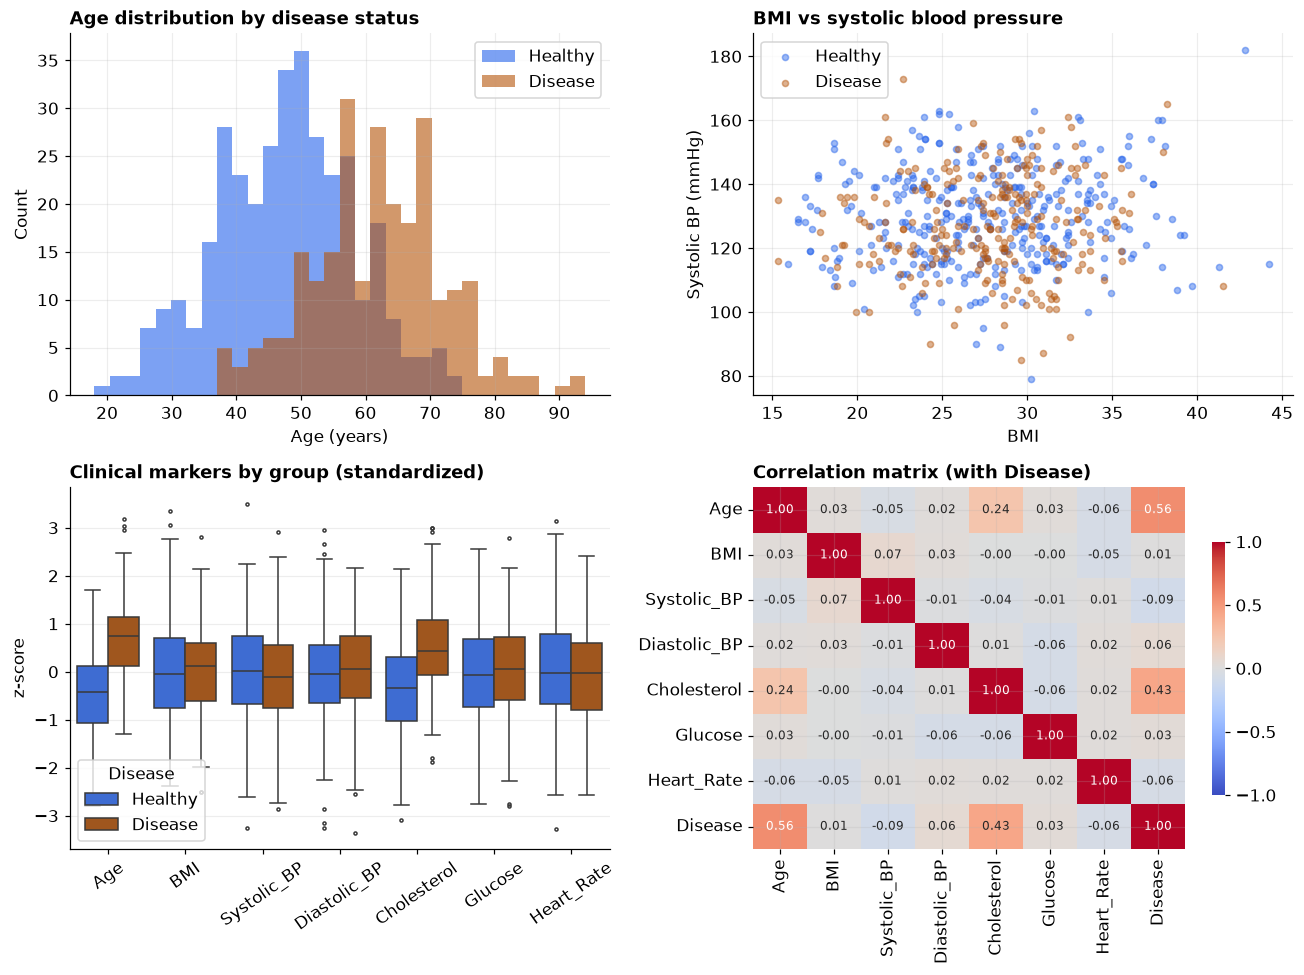

In [4]:
clean = raw.copy()   # a light copy just for exploring; formal cleaning is Step 5
clean = clean[(clean.Age.between(18,100)) & (clean.BMI.between(12,70)) & (clean.Systolic_BP.between(70,250))]
fig, ax = plt.subplots(2, 2, figsize=(12, 9))
# (a) Age by disease
for g in [0,1]:
    ax[0,0].hist(clean[clean.Disease==g].Age, bins=24, alpha=0.6, color=PAL[g], label=["Healthy","Disease"][g])
ax[0,0].set_title("Age distribution by disease status"); ax[0,0].set_xlabel("Age (years)"); ax[0,0].set_ylabel("Count"); ax[0,0].legend()
# (b) BMI vs Systolic scatter
for g in [0,1]:
    s = clean[clean.Disease==g]
    ax[0,1].scatter(s.BMI, s.Systolic_BP, s=16, alpha=0.45, color=PAL[g], label=["Healthy","Disease"][g])
ax[0,1].set_title("BMI vs systolic blood pressure"); ax[0,1].set_xlabel("BMI"); ax[0,1].set_ylabel("Systolic BP (mmHg)"); ax[0,1].legend()
# (c) standardized marker boxplots by disease
z = clean[MARKERS].apply(lambda c: (c - c.mean())/c.std())
zl = z.assign(Disease=clean.Disease.map({0:"Healthy",1:"Disease"})).melt(id_vars="Disease", var_name="Marker", value_name="z")
sns.boxplot(data=zl, x="Marker", y="z", hue="Disease", palette=[BL,GOLD], ax=ax[1,0], fliersize=2)
ax[1,0].set_title("Clinical markers by group (standardized)"); ax[1,0].set_xlabel(""); ax[1,0].set_ylabel("z-score")
ax[1,0].tick_params(axis="x", rotation=35)
# (d) correlation matrix incl Disease
corr = clean[MARKERS + ["Disease"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1, ax=ax[1,1], cbar_kws={"shrink":0.7}, annot_kws={"size":8})
ax[1,1].set_title("Correlation matrix (with Disease)")
plt.tight_layout(); plt.show()

**Reading the dashboard.** The four panels agree on one story. Age (top-left) shows the clearest separation: diseased patients skew older. The BMI-versus-blood-pressure scatter (top-right) is a single overlapping cloud, the two groups are not separated by either of those markers. The standardized boxplots (bottom-left) put every marker on one scale, and only Age and Cholesterol show a visible gap between the blue and gold boxes. The correlation matrix (bottom-right) makes it numeric: in the `Disease` row, Age (about 0.55) and Cholesterol (about 0.42) stand out, while every other marker sits near zero. Everything points to two real signals and five quiet markers, which is exactly what the formal screen has to confirm without being fooled by chance.

## Step 5 &middot; Prepare and clean
The raw export carries missing values, impossible entries, and duplicate rows. We drop duplicates, then remove any value outside a clinically plausible range for its marker, then drop rows still missing a marker we need.

In [5]:
RANGES = {"Age":(18,100),"BMI":(12,70),"Systolic_BP":(70,250),"Diastolic_BP":(40,150),
          "Cholesterol":(80,450),"Glucose":(50,400),"Heart_Rate":(35,200)}
df = raw.drop_duplicates(); after_dup = len(df)
removed = {}
for m,(lo,hi) in RANGES.items():
    bad = df[m].notna() & ~df[m].between(lo,hi)
    removed[m] = int(bad.sum())
    df = df[~bad]
df = df.dropna(subset=MARKERS).copy()
print(f"start {len(raw)}  ->  dedup {after_dup} (-{len(raw)-after_dup})  ->  range+missing clean {len(df)}")
print("out-of-range values removed per marker:", {k:v for k,v in removed.items() if v})
print(f"clean analysis sample: n = {len(df)}   (disease {int(df.Disease.sum())}, healthy {int((1-df.Disease).sum())})")

start 603  ->  dedup 600 (-3)  ->  range+missing clean 575
out-of-range values removed per marker: {'Age': 2, 'BMI': 2, 'Systolic_BP': 1, 'Glucose': 12}
clean analysis sample: n = 575   (disease 242, healthy 333)


**What cleaning cost us.** About 5% of rows were affected, three duplicate log rows, a few impossible ages, BMIs, and a zero blood pressure, plus some out-of-range or missing lab values, leaving 575 of the 600 patients. The clean sample is essentially the full cohort, so the conclusions rest on the whole group, not a survivor subset.

## Step 6 &middot; Name the design
For each marker this is a two-sample comparison, healthy versus disease, on a continuous outcome, the same design as Capstone 2. What is new is that we run it **seven times**. Each individual test is fine; the danger is in the collection.

## Step 7 &middot; Assumptions, briefly
With a few hundred patients per group, the Central Limit Theorem makes the two-sample **Welch t-test** (unequal variances allowed) trustworthy for each marker, and Welch is the safe default anyway. For any marker that looked skewed we would fall back to the rank-based Mann-Whitney test, but here the choice does not change the verdict, so we report Welch throughout.

## Step 8 &middot; The multiple-comparisons problem
Here is the trap. If a marker has no real association, a single test still flags it as "significant" about 5% of the time by chance. Run **seven** independent tests and the chance that **at least one** clean marker lights up by luck is much higher.

In [6]:
alpha = 0.05; k = len(MARKERS)
fwer = 1 - (1 - alpha)**k
print(f"per-test false-positive rate: {alpha:.0%}")
print(f"testing {k} markers, chance of at least one false alarm: 1 - (1-{alpha})^{k} = {fwer:.0%}")
print(f"\nBonferroni fix: require p < alpha/k = {alpha}/{k} = {alpha/k:.4f} for each test")
print("Holm fix: a smarter step-down version of Bonferroni, same family-wise guarantee but more powerful")

per-test false-positive rate: 5%
testing 7 markers, chance of at least one false alarm: 1 - (1-0.05)^7 = 30%

Bonferroni fix: require p < alpha/k = 0.05/7 = 0.0071 for each test
Holm fix: a smarter step-down version of Bonferroni, same family-wise guarantee but more powerful


**Why this matters here.** With seven markers, there is about a **30%** chance that a completely unrelated marker crosses the 0.05 line on luck alone. The cure is to raise the bar. **Bonferroni** simply divides the threshold by the number of tests (here, 0.05 / 7 = 0.0071). **Holm** achieves the same protection while rejecting slightly more true effects. We apply both and see which markers survive.

## Step 9 &middot; Choose the analysis
- **Per marker:** Welch two-sample t-test (healthy vs disease), with Cohen's d and a 95% CI for the difference.
- **Across markers:** correct the seven p-values with **Bonferroni** and **Holm** to control the family-wise error rate.
- **A second view:** the point-biserial correlation of each marker with the binary `Disease`, which tells the same story as the t-test from the correlation angle.

## Step 10 &middot; Run the screen, then correct it
We loop over the seven markers, run Welch's test, record the effect size and correlation, then apply the corrections to the whole set of p-values at once.

In [7]:
rows = []
for m in MARKERS:
    a = df[df.Disease==0][m]; b = df[df.Disease==1][m]
    t, p = stats.ttest_ind(a, b, equal_var=False)
    d = abs(a.mean()-b.mean()) / np.sqrt((a.var(ddof=1)+b.var(ddof=1))/2)   # Cohen's d (pooled)
    r_pb = stats.pointbiserialr(df.Disease, df[m]).statistic
    rows.append({"marker":m, "healthy":round(a.mean(),1), "disease":round(b.mean(),1),
                 "p_raw":p, "cohen_d":round(d,3), "r_pb":round(r_pb,3)})
res = pd.DataFrame(rows)
res["bonferroni"] = multipletests(res.p_raw, method="bonferroni", alpha=0.05)[0]
res["holm"]       = multipletests(res.p_raw, method="holm", alpha=0.05)[0]
res["raw_sig"]    = res.p_raw < 0.05
res = res.sort_values("cohen_d", ascending=False).reset_index(drop=True)
show = res.copy(); show["p_raw"] = show.p_raw.map(lambda x: f"{x:.2e}")
print(show.to_string(index=False))

      marker  healthy  disease    p_raw  cohen_d   r_pb  bonferroni  holm  raw_sig
         Age     47.5     61.7 2.98e-47    1.344  0.552        True  True     True
 Cholesterol    197.8    234.6 8.28e-27    0.953  0.425        True  True     True
 Systolic_BP    129.7    126.7 2.09e-02    0.196 -0.097       False False     True
Diastolic_BP     82.0     83.2 1.74e-01    0.115  0.057       False False    False
  Heart_Rate     74.9     73.8 2.08e-01    0.106 -0.052       False False    False
     Glucose     97.4     98.8 4.43e-01    0.065  0.032       False False    False
         BMI     27.6     27.6 9.19e-01    0.008  0.004       False False    False


**Read the table top to bottom.** Ranked by effect size, **Age** (Cohen's d about 1.3) and **Cholesterol** (d about 0.95) are in a different league from the rest, and both clear even the strict Bonferroni bar. Now look at **Systolic_BP**: its raw p-value is below 0.05, so on a naive reading it "matters", yet its effect size is tiny (d about 0.2) and, crucially, it does **not** survive either correction. It is the false alarm the previous step warned about, a marker with no real group difference that crossed 0.05 because we tested seven things. The remaining markers are not significant even before correction.

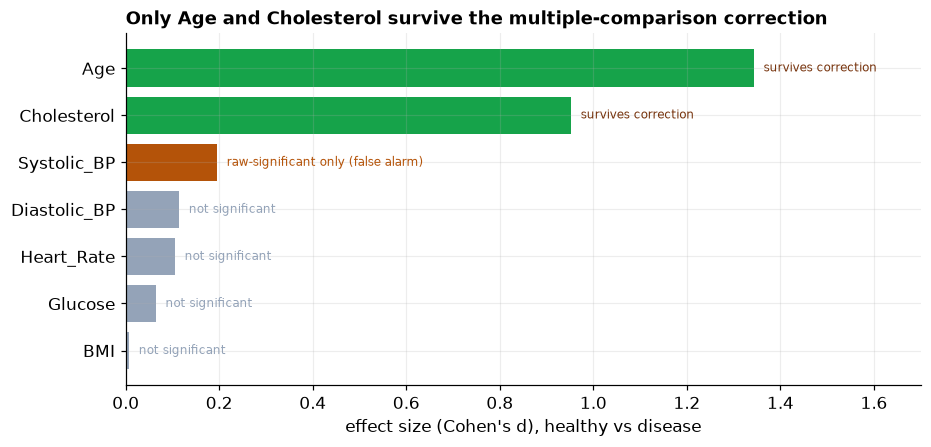

In [8]:
# The screen in one picture: effect size per marker, colored by whether it survives correction.
order = res.sort_values("cohen_d")
colors = [GR if h else (GOLD if rs else MUT) for h, rs in zip(order.holm, order.raw_sig)]
fig, ax = plt.subplots(figsize=(8.6, 4.2))
ax.barh(order.marker, order.cohen_d, color=colors)
for y,(d,rs,h) in enumerate(zip(order.cohen_d, order.raw_sig, order.holm)):
    tag = "survives correction" if h else ("raw-significant only (false alarm)" if rs else "not significant")
    ax.text(d+0.02, y, tag, va="center", fontsize=8, color=DARK if h else (GOLD if rs else MUT))
ax.set_xlabel("effect size (Cohen's d), healthy vs disease"); ax.set_xlim(0, 1.7)
ax.set_title("Only Age and Cholesterol survive the multiple-comparison correction")
plt.tight_layout(); plt.show()

**The picture makes the discipline obvious.** Green bars are the markers that hold up after correcting for seven tests; the gold bar (Systolic BP) is significant only until you account for multiple comparisons; the grey bars never reached significance. Effect size and correction together separate the two genuine signals from the noise.

## Step 11 &middot; The correction, seen as intervals instead of p-values
Correcting for multiple comparisons is usually shown as a shrinking p-value threshold, which is abstract. The same correction has a concrete visual form: **the confidence intervals get wider**. Seven markers tested at a family-wise 5 percent means each individual interval must be a 99.29 percent interval.

In [9]:
from scipy.stats import t as tdist

def d_ci(a, b, conf):
    """CI for Cohen's d between two independent groups, via the standard error of d."""
    n1, n2 = len(a), len(b)
    sp = np.sqrt(((n1-1)*a.var(ddof=1) + (n2-1)*b.var(ddof=1)) / (n1+n2-2))
    dd = (a.mean() - b.mean()) / sp
    se = np.sqrt((n1+n2)/(n1*n2) + dd**2/(2*(n1+n2)))
    crit = stats.norm.ppf(1 - (1-conf)/2)
    return dd, dd - crit*se, dd + crit*se

conf_adj = 1 - alpha/k          # Bonferroni: 1 - 0.05/7
print(f"individual confidence level required for a family-wise 5%: {conf_adj*100:.2f}%\n")
print(f"{'marker':14s} {'d':>6s}  {'95% CI':>18s}  {'99.29% CI (adjusted)':>22s}  verdict")
print("-"*82)
rows_ci = []
for m in MARKERS:
    a = df[df.Disease == 1][m].values.astype(float)
    b = df[df.Disease == 0][m].values.astype(float)
    dd, l95, h95 = d_ci(a, b, 0.95)
    _,  lad, had = d_ci(a, b, conf_adj)
    survives = not (lad <= 0 <= had)
    rows_ci.append((m, dd, l95, h95, lad, had, survives))
    print(f"{m:14s} {dd:+6.2f}  [{l95:+6.2f}, {h95:+6.2f}]  [{lad:+6.2f}, {had:+6.2f}]  "
          f"{'survives' if survives else 'crosses zero'}")
ci_tab = pd.DataFrame(rows_ci, columns=["marker","d","lo95","hi95","lo_adj","hi_adj","survives"])

individual confidence level required for a family-wise 5%: 99.29%

marker              d              95% CI    99.29% CI (adjusted)  verdict
----------------------------------------------------------------------------------
Age             +1.34  [ +1.16,  +1.52]  [ +1.09,  +1.59]  survives
BMI             +0.01  [ -0.16,  +0.17]  [ -0.22,  +0.24]  crosses zero
Systolic_BP     -0.20  [ -0.36,  -0.03]  [ -0.42,  +0.03]  crosses zero
Diastolic_BP    +0.11  [ -0.05,  +0.28]  [ -0.11,  +0.34]  crosses zero
Cholesterol     +0.95  [ +0.77,  +1.12]  [ +0.71,  +1.19]  survives
Glucose         +0.06  [ -0.10,  +0.23]  [ -0.16,  +0.29]  crosses zero
Heart_Rate      -0.10  [ -0.27,  +0.06]  [ -0.33,  +0.12]  crosses zero


**The same decision, told a better way.** Systolic blood pressure is the case worth studying. Its ordinary 95 percent interval sits entirely above zero, which is why it looked like a finding. Widen it to the 99.29 percent interval the family of seven tests requires, and it **crosses zero**. Nothing about the data changed; the standard of evidence did, and that marker no longer clears it.

Age and cholesterol are untouched by the widening. Their intervals stay far from zero either way, which is what a robust finding looks like: it does not depend on how generous you are being with the threshold.

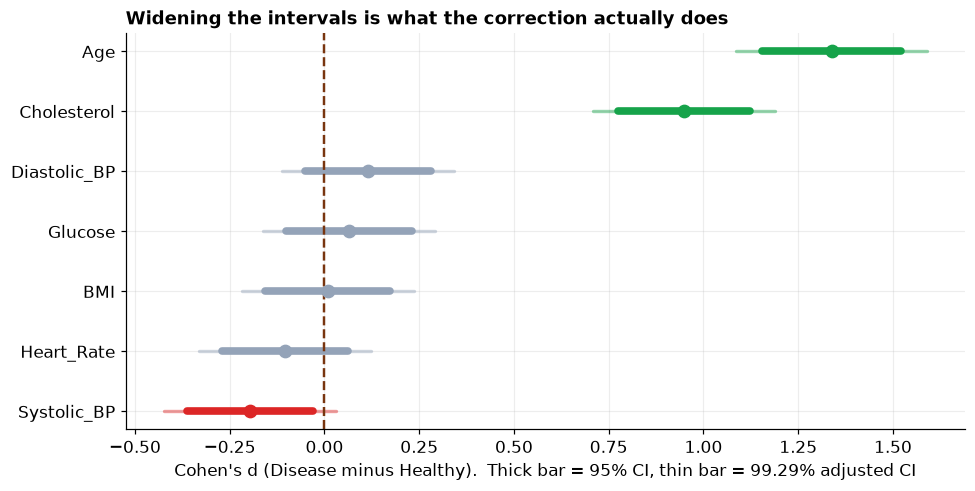

Green: survives the correction. Red: significant raw, killed by it. Grey: never significant.


In [10]:
fig, ax = plt.subplots(figsize=(9.0, 4.6))
order = ci_tab.sort_values("d").reset_index(drop=True)
ys = np.arange(len(order))
for i, r in order.iterrows():
    col = GR if r.survives else (RD if r.lo95 > 0 or r.hi95 < 0 else MUT)
    ax.plot([r.lo_adj, r.hi_adj], [i, i], color=col, lw=2.2, alpha=0.45, solid_capstyle="round")
    ax.plot([r.lo95, r.hi95], [i, i], color=col, lw=5.0, solid_capstyle="round")
    ax.plot(r.d, i, "o", color=col, ms=8, zorder=3)
ax.axvline(0, color=DARK, lw=1.6, ls="--")
ax.set_yticks(ys); ax.set_yticklabels(order.marker)
ax.set_xlabel("Cohen's d (Disease minus Healthy).  Thick bar = 95% CI, thin bar = 99.29% adjusted CI")
ax.set_title("Widening the intervals is what the correction actually does")
plt.tight_layout(); plt.show()
print("Green: survives the correction. Red: significant raw, killed by it. Grey: never significant.")

**The picture of the multiple-comparisons problem.** Each marker shows a thick bar (the ordinary interval) and a thin one (the interval the family of seven demands). For age and cholesterol both bars sit clear of the dashed zero line. For systolic blood pressure the thick bar clears zero and the thin bar does not, which is precisely the false alarm the Holm procedure caught, drawn rather than asserted.

## Step 12 &middot; Interpret in plain language
Two markers genuinely distinguish diseased from healthy patients in this cohort: **age** and **cholesterol**, both with large, clearly significant differences that survive any correction. **Blood pressure looked significant** on a first pass, which is tempting to believe because we expect blood pressure to matter for heart disease, but it was a **false positive** produced by testing seven markers at once, and it vanishes under correction. The lesson is the method as much as the result: when you screen many variables, correct for it, and read the effect size, not just the p-value.

## Step 13 &middot; Ethics, bias, and limits
- **Association is not causation.** This is observational data with no intervention. Age and cholesterol are *associated* with disease here; that does not prove either causes it.
- **Confounding.** Age is the elephant in the room: older patients tend to have higher cholesterol and more disease, so part of cholesterol's apparent signal could be age riding along. Separating them needs a model that adjusts for age (regression), not seven separate tests.
- **The screen is a starting point, not a diagnosis.** Finding that a marker differs between groups does not make it a good individual predictor, and it says nothing about any one patient.
- **Multiple testing is an integrity issue, not just a technicality.** Reporting the one marker that crossed 0.05 out of seven, without mentioning the other six, is how false findings get published. The correction is what keeps the screen honest.

---
**From analysis to report.** The notebook produced the dashboard, the corrected screen, and the effect sizes. The written report turns it into a one-page brief for a clinical audience: which markers are worth pursuing, why blood pressure did not make the cut, and the caution that this is association, not cause. Automate the evidence; author the argument.